In [1]:
import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn xgboost scikit-image pillow matplotlib seaborn scipy
#hello world


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray, rgb2hsv
from skimage import img_as_ubyte

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

import xgboost as xgb

In [5]:
import os

# Images are inside ham_images folder
IMG_DIRS = [
    "C:\\Users\\HP\\OneDrive\\Desktop\\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\\ham_images\\HAM10000_images_part_1",
    "C:\\Users\\HP\\OneDrive\\Desktop\\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\\ham_images\\HAM10000_images_part_2"
]

for folder in IMG_DIRS:
    count = len([f for f in os.listdir(folder) if f.endswith(".jpg")])
    print(f"✅ {folder}: {count} images")

✅ C:\Users\HP\OneDrive\Desktop\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\ham_images\HAM10000_images_part_1: 5000 images
✅ C:\Users\HP\OneDrive\Desktop\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\ham_images\HAM10000_images_part_2: 5015 images


In [7]:
DATA_DIR  = "."
META_CSV  = r"C:\Users\HP\OneDrive\Desktop\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\HAM10000_metadata.csv"

IMG_DIRS = [
    r"C:\Users\HP\OneDrive\Desktop\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\ham_images\HAM10000_images_part_1",
    r"C:\Users\HP\OneDrive\Desktop\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\ham_images\HAM10000_images_part_2"
]

IMG_SIZE    = (128, 128)
RANDOM_SEED = 42

In [8]:
import os
print(os.listdir())

['.git', '.gitignore', 'data_preprocess_eda.ipynb', 'HAM10000_metadata.csv', 'ham_images', 'preprocessing_validation.png', 'processed_ids.npy', 'processed_images.npy', 'README.md']


In [9]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import cv2

def load_image(image_id):
    img_name = image_id + ".jpg"
    
    for d in IMG_DIRS:
        path = os.path.join(d, img_name)
        if os.path.exists(path):
            return cv2.imread(path)
    
    return None

In [12]:
import pandas as pd

df = pd.read_csv("HAM10000_metadata.csv")

img = load_image(df.iloc[0]['image_id'])

print(img.shape)

(450, 600, 3)


In [13]:
# 1.  LABEL MAP
# ─────────────────────────────────────────────
LABEL_MAP = {
    "mel":  "Melanoma",
    "bcc":  "Basal Cell Carcinoma",
    "akiec":"Actinic Keratoses",
    "bkl":  "Benign Keratosis",
    "df":   "Dermatofibroma",
    "nv":   "Melanocytic Nevi",
    "vasc": "Vascular Lesions",
}

In [14]:
# ── Stage 2: Dataset Overview ─────────────────────────────────────────────
df = pd.read_csv("HAM10000_metadata.csv")
df['label_name'] = df['dx'].map(LABEL_MAP)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total records      : {len(df)}")
print(f"Unique lesion IDs  : {df['lesion_id'].nunique()}")
print(f"Unique image IDs   : {df['image_id'].nunique()}")
print(f"Number of columns  : {df.shape[1]}")
print(f"\nColumn names       : {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nClass distribution:\n{df['label_name'].value_counts()}")
print(f"\nSex distribution:\n{df['sex'].value_counts()}")
print(f"\nLocalization distribution:\n{df['localization'].value_counts()}")
print(f"\nDiagnosis confirmation methods:\n{df['dx_type'].value_counts()}")

# Verify all images are findable
def get_image_path(image_id):
    for d in IMG_DIRS:
        path = os.path.join(d, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

df['img_path'] = df['image_id'].apply(get_image_path)
missing = df['img_path'].isna().sum()
print(f"\nMissing images     : {missing}")
df = df[df['img_path'].notna()].reset_index(drop=True)
print(f"Usable records     : {len(df)}")


DATASET OVERVIEW
Total records      : 10015
Unique lesion IDs  : 7470
Unique image IDs   : 10015
Number of columns  : 8

Column names       : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label_name']

Data types:
lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
label_name          str
dtype: object

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
label_name       0
dtype: int64

Class distribution:
label_name
Melanocytic Nevi        6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratoses        327
Vascular Lesions         142
Dermatofibroma           115
Name: count, dtype: int64

Sex distribution:
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64



##PREPROCESSING

Loaded 10015 preprocessed images from cache

PREPROCESSING VALIDATION
Image array shape  : (10015, 128, 128, 3)   (N, H, W, C)
Data type (stored) : uint8  — uint8 saves memory
Pixel value range  : [0, 255] → normalized [0.0, 1.0] per image during feature extraction
Sample pixel mean  : 0.7641
Sample pixel std   : 0.0795
Per-channel means  : R=0.8393  G=0.6803  B=0.7727


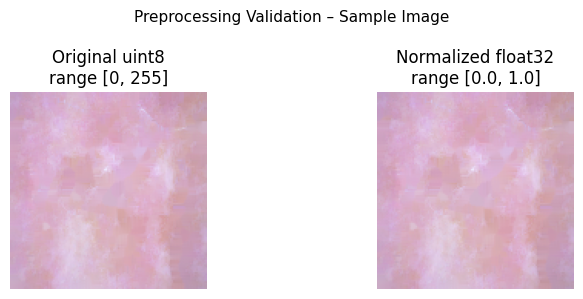

Validation plot saved → preprocessing_validation.png


In [16]:
# ── Stage 3: Preprocessing Pipeline ───────────────────────────────────────
import cv2

def preprocess_image(img_path, size=IMG_SIZE):
    """Load, resize, convert BGR→RGB."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def remove_hair(img):
    """Inpainting-based hair removal."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(img, mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return cleaned

PROCESSED_NPY = "processed_images.npy"
PROCESSED_IDS = "processed_ids.npy"

if not os.path.exists(PROCESSED_NPY):
    images_raw, ids = [], []
    for _, row in df.iterrows():
        img = preprocess_image(row['img_path'])
        if img is not None:
            img = remove_hair(img)
            images_raw.append(img)
            ids.append(row['image_id'])
    images_uint8 = np.array(images_raw, dtype=np.uint8)
    np.save(PROCESSED_NPY, images_uint8)
    np.save(PROCESSED_IDS, np.array(ids))
    print(f"Saved {len(images_uint8)} preprocessed images → {PROCESSED_NPY}")
else:
    images_uint8 = np.load(PROCESSED_NPY)
    ids = np.load(PROCESSED_IDS)
    print(f"Loaded {len(images_uint8)} preprocessed images from cache")

# Align df to saved order
id_to_idx = {iid: i for i, iid in enumerate(ids)}
df = df[df['image_id'].isin(id_to_idx)].copy()
df['proc_idx'] = df['image_id'].map(id_to_idx)
df = df.sort_values('proc_idx').reset_index(drop=True)
images_uint8 = images_uint8[df['proc_idx'].values]

# ── Validation Output (normalize only 1 sample, not all 10015) ────────────
sample = images_uint8[0]
sample_float = sample.astype(np.float32) / 255.0

print("\n" + "=" * 60)
print("PREPROCESSING VALIDATION")
print("=" * 60)
print(f"Image array shape  : {images_uint8.shape}   (N, H, W, C)")
print(f"Data type (stored) : {images_uint8.dtype}  — uint8 saves memory")
print(f"Pixel value range  : [0, 255] → normalized [0.0, 1.0] per image during feature extraction")
print(f"Sample pixel mean  : {sample_float.mean():.4f}")
print(f"Sample pixel std   : {sample_float.std():.4f}")
print(f"Per-channel means  : R={sample_float[:,:,0].mean():.4f}  "
      f"G={sample_float[:,:,1].mean():.4f}  B={sample_float[:,:,2].mean():.4f}")

# Free memory — uint8 array stays, float32 sample discarded
del sample_float

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(images_uint8[0])
axes[0].set_title("Original uint8\nrange [0, 255]")
axes[0].axis('off')
axes[1].imshow(images_uint8[0].astype(np.float32) / 255.0)
axes[1].set_title("Normalized float32\nrange [0.0, 1.0]")
axes[1].axis('off')
plt.suptitle("Preprocessing Validation – Sample Image", fontsize=11)
plt.tight_layout()
plt.savefig("preprocessing_validation.png", dpi=150)
plt.show()
print("Validation plot saved → preprocessing_validation.png")

# images_uint8 is your main image array going forward
# Normalization happens per-image inside feature extraction functions
images = images_uint8  # keep this name consistent with rest of notebook

##EXPLORATORY DATA ANALYSIS

In [17]:
print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)

print("Total samples:", len(df))
print("\nClass distribution:\n", df['label_name'].value_counts())

print("\nSex distribution:\n", df['sex'].value_counts())
print("\nLocalization:\n", df['localization'].value_counts())

print("\nMissing values:\n", df.isnull().sum())

FINAL DATASET SUMMARY
Total samples: 10015

Class distribution:
 label_name
Melanocytic Nevi        6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratoses        327
Vascular Lesions         142
Dermatofibroma           115
Name: count, dtype: int64

Sex distribution:
 sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

Localization:
 localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

Missing values:
 lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
label_name       0
img_path    

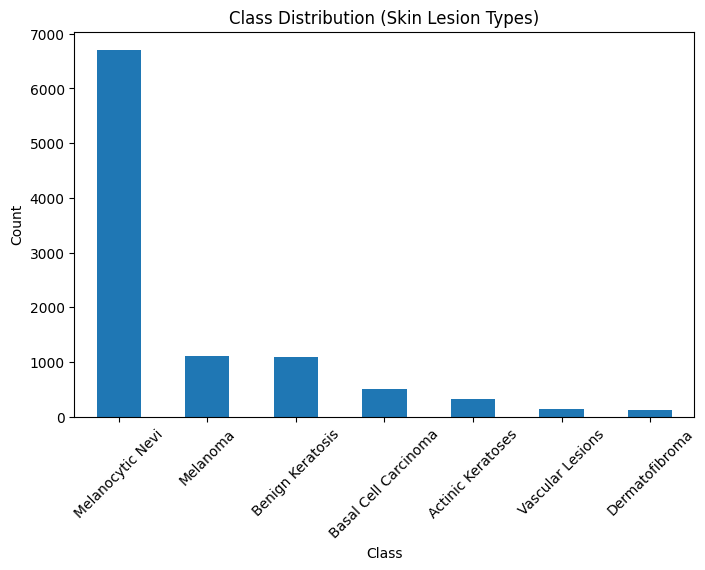

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['label_name'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Skin Lesion Types)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

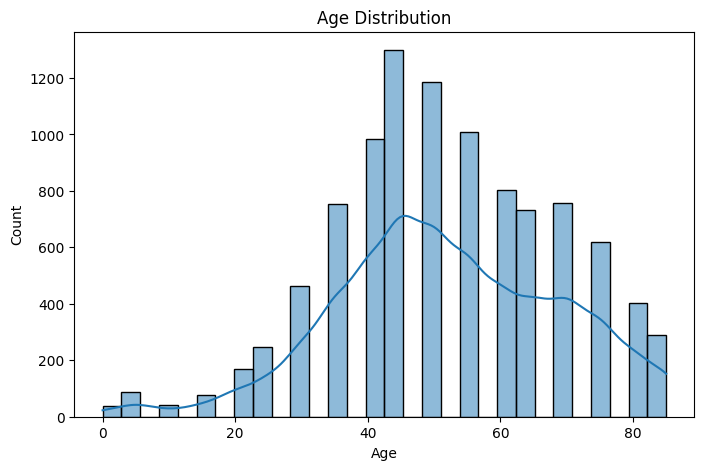

In [19]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

In [20]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['age'] >= lower) & (df['age'] <= upper)]

print("Before:", len(df))
print("After removing age outliers:", len(df_clean))

Before: 10015
After removing age outliers: 9919


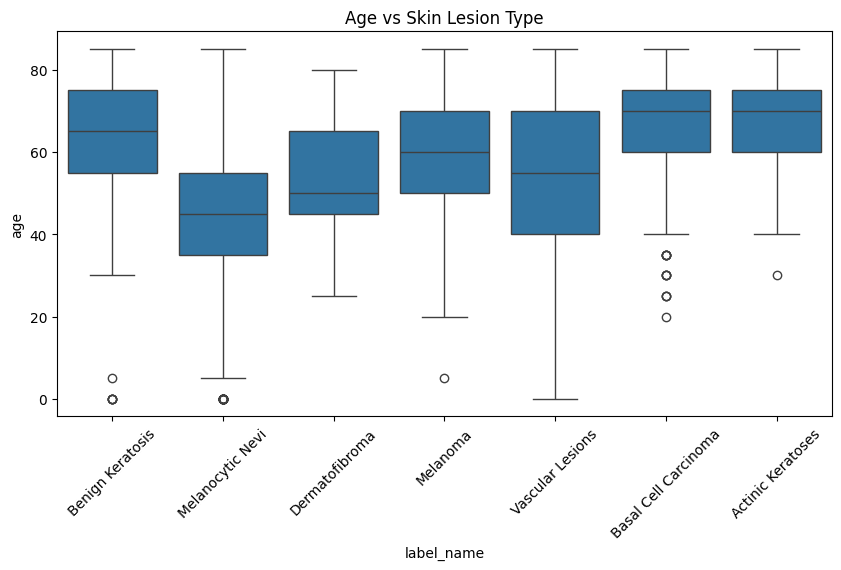

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(x='label_name', y='age', data=df)
plt.xticks(rotation=45)
plt.title("Age vs Skin Lesion Type")
plt.show()

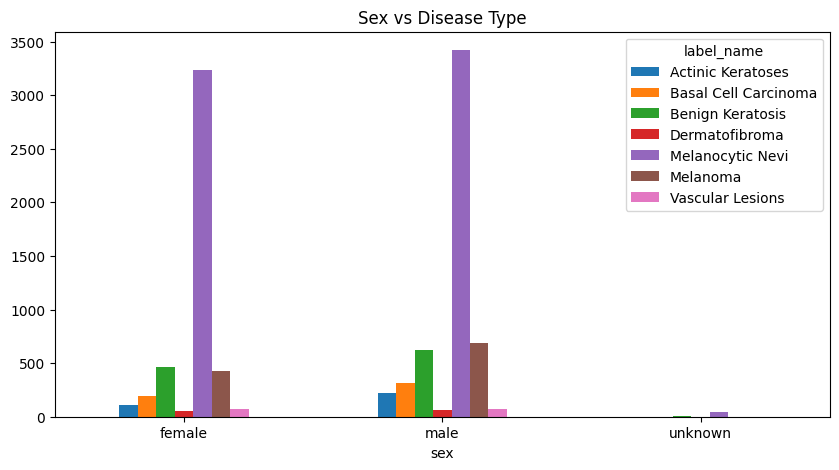

In [24]:
pd.crosstab(df['sex'], df['label_name']).plot(kind='bar', figsize=(10,5))
plt.title("Sex vs Disease Type")
plt.xticks(rotation=0)
plt.show()

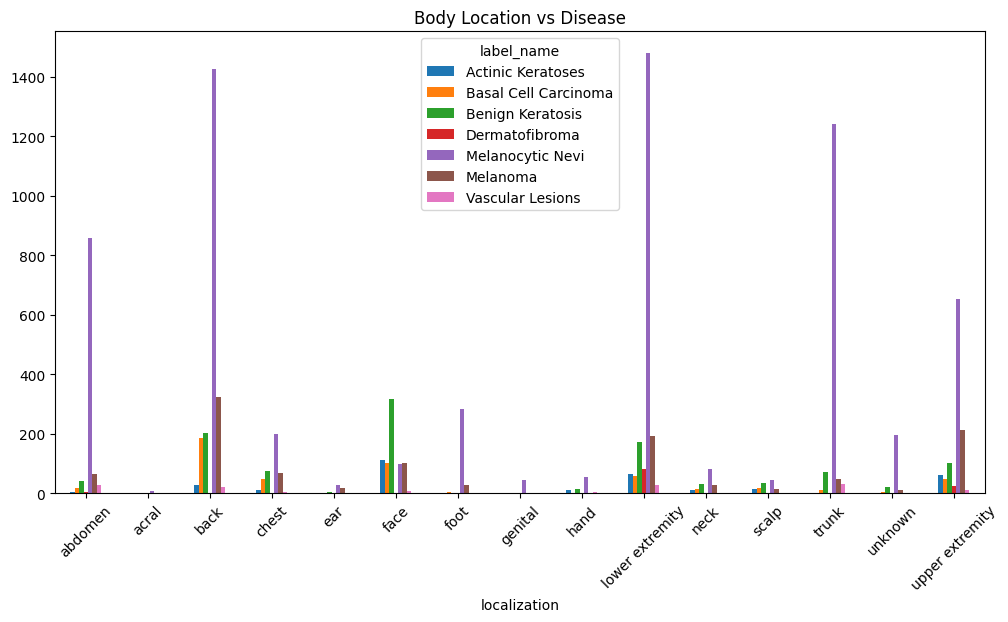

In [25]:
pd.crosstab(df['localization'], df['label_name']).plot(kind='bar', figsize=(12,6))
plt.title("Body Location vs Disease")
plt.xticks(rotation=45)
plt.show()

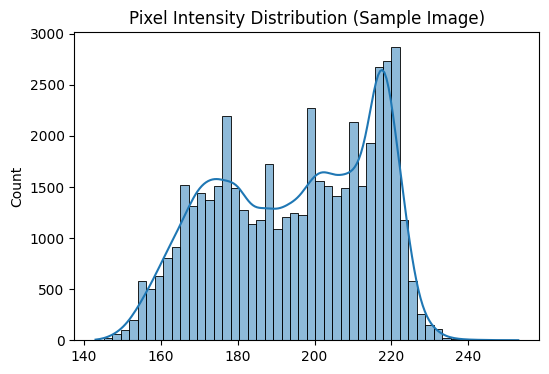

In [26]:
import numpy as np

sample_pixels = images[0].flatten()

plt.figure(figsize=(6,4))
sns.histplot(sample_pixels, bins=50, kde=True)
plt.title("Pixel Intensity Distribution (Sample Image)")
plt.show()

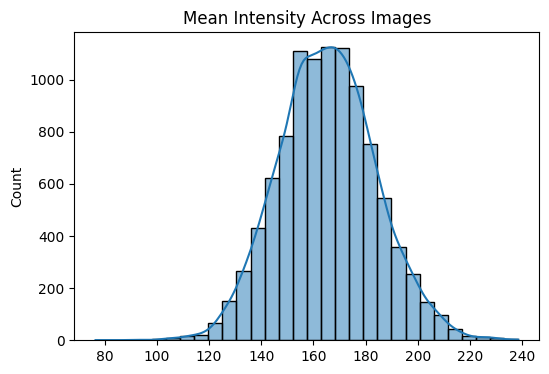

In [35]:
mean_intensity = [img.mean() for img in images]

plt.figure(figsize=(6,4))
sns.histplot(mean_intensity, bins=30, kde=True)
plt.title("Mean Intensity Across Images")
plt.show()

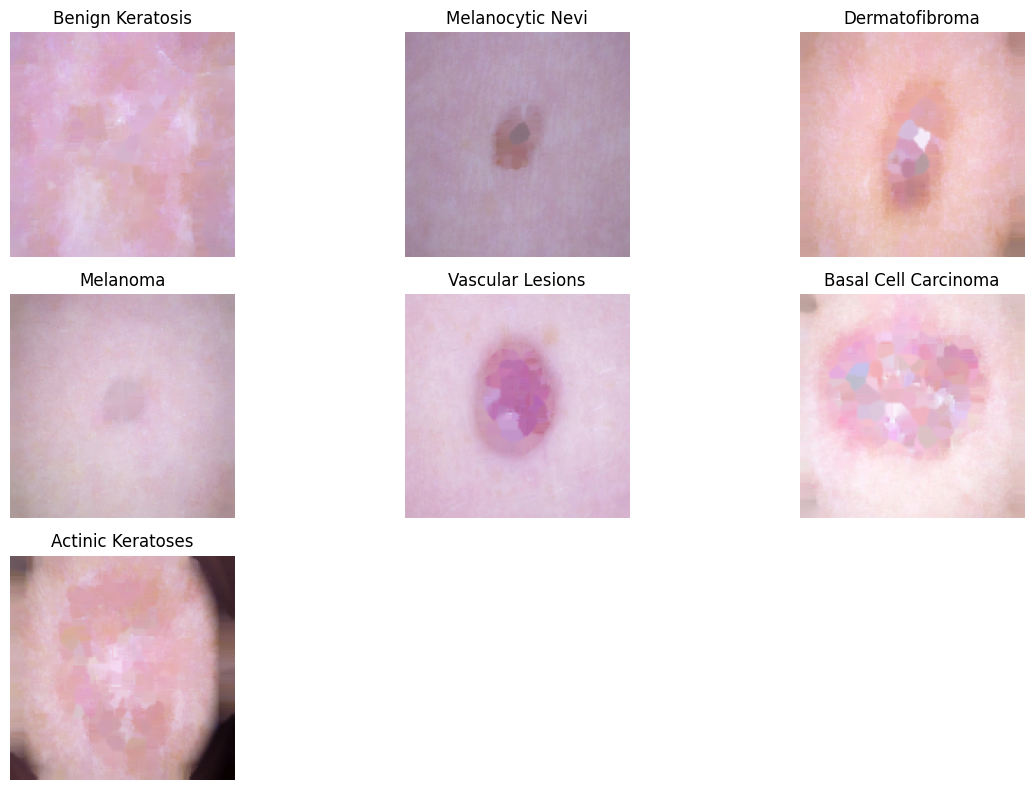

In [29]:
import random

classes = df['label_name'].unique()

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    idx = df[df['label_name'] == cls].index[0]
    
    plt.subplot(3, 3, i+1)
    plt.imshow(images[idx])
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
class_counts = df['label_name'].value_counts()

print("\nClass Imbalance Ratio:")
print(class_counts / len(df))


Class Imbalance Ratio:
label_name
Melanocytic Nevi        0.669496
Melanoma                0.111133
Benign Keratosis        0.109735
Basal Cell Carcinoma    0.051323
Actinic Keratoses       0.032651
Vascular Lesions        0.014179
Dermatofibroma          0.011483
Name: count, dtype: float64


In [31]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from tqdm import tqdm
import os

# GLCM Feature Extraction Function
def extract_glcm_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128, 128))
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Compute GLCM
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256,
        symmetric=True,
        normed=True
    )

    features = []
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']

    for prop in props:
        val = graycoprops(glcm, prop)
        features.extend(val.flatten())

    return features


# Dataset path
dataset_path = r"C:\Users\HP\OneDrive\Desktop\Skin-Lesion-Type-Classification-Using-Texture-and-Color-Features-with-SVM\ham_images"

data = []
labels = []

# Loop through folders (each folder = class)
for label in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, label)
    
    if os.path.isdir(class_path):
        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)

            try:
                features = extract_glcm_features(img_path)
                data.append(features)
                labels.append(label)
            except:
                continue

# Create DataFrame
columns = []
props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
angles = ['0', '45', '90', '135']

for prop in props:
    for angle in angles:
        columns.append(f"{prop}_{angle}")

df = pd.DataFrame(data, columns=columns)
df['label'] = labels

print(df.head())

100%|██████████| 5015/5015 [05:59<00:00, 13.95it/s]


   contrast_0  contrast_45  contrast_90  contrast_135  dissimilarity_0  \
0   41.972256    57.618637    29.921567     39.119164         4.020731   
1   34.233391    36.703019    20.997047     41.314527         3.727854   
2   70.184916    77.891686    81.910556    117.511625         5.437746   
3   21.315330    23.431769    18.451280     31.397731         3.355438   
4  116.412771   139.067580    94.028851    160.321161         7.842028   

   dissimilarity_45  dissimilarity_90  dissimilarity_135  homogeneity_0  \
0          4.596379          3.389456           4.299895       0.257174   
1          3.962490          3.273622           4.288425       0.263879   
2          5.691549          5.762672           7.079484       0.232783   
3          3.557877          3.107160           4.053568       0.266915   
4          8.470767          7.013472           9.224750       0.134927   

   homogeneity_45  ...  homogeneity_135  energy_0  energy_45  energy_90  \
0        0.232724  ...       

In [37]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

def extract_hsv_features(image_path):
    """Extract 48 HSV histogram features (16 bins x 3 channels)."""
    img = cv2.imread(image_path)
    img = cv2.resize(img, (128, 128))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h_hist = cv2.calcHist([hsv], [0], None, [16], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], None, [16], [0, 256]).flatten()
    v_hist = cv2.calcHist([hsv], [2], None, [16], [0, 256]).flatten()

    # L1 normalise each histogram
    h_hist = h_hist / (h_hist.sum() + 1e-9)
    s_hist = s_hist / (s_hist.sum() + 1e-9)
    v_hist = v_hist / (v_hist.sum() + 1e-9)

    return np.concatenate([h_hist, s_hist, v_hist])   # 48 values

# Same folder structure as GLCM cell
dataset_path = "ham_images"

hsv_data   = []
hsv_labels = []
hsv_ids    = []

for label in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, label)
    if not os.path.isdir(class_path):
        continue
    for img_name in tqdm(os.listdir(class_path), desc=label):
        img_path = os.path.join(class_path, img_name)
        try:
            feat = extract_hsv_features(img_path)
            hsv_data.append(feat)
            hsv_labels.append(label)
            hsv_ids.append(img_name.replace(".jpg", ""))
        except Exception:
            continue

hsv_cols = ([f"H_bin{i}" for i in range(16)] +
            [f"S_bin{i}" for i in range(16)] +
            [f"V_bin{i}" for i in range(16)])

hsv_df = pd.DataFrame(hsv_data, columns=hsv_cols)
hsv_df["label"]    = hsv_labels
hsv_df["image_id"] = hsv_ids

print("HSV feature shape:", hsv_df.shape)
print(hsv_df.head(3))


HAM10000_images_part_1:   0%|          | 0/5000 [00:00<?, ?it/s]

HAM10000_images_part_2: 100%|██████████| 5015/5015 [00:38<00:00, 130.94it/s]


HSV feature shape: (10015, 50)
     H_bin0  H_bin1  H_bin2  H_bin3  H_bin4  H_bin5  H_bin6  H_bin7  H_bin8  \
0  0.556274     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
1  0.253784     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2  0.540955     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

   H_bin9  ...    V_bin8    V_bin9   V_bin10   V_bin11   V_bin12   V_bin13  \
0     0.0  ...  0.012939  0.018921  0.033386  0.050903  0.084045  0.250916   
1     0.0  ...  0.000000  0.000061  0.010193  0.045105  0.119812  0.536560   
2     0.0  ...  0.044556  0.053284  0.055786  0.051514  0.049988  0.097412   

    V_bin14   V_bin15                   label      image_id  
0  0.478455  0.042542  HAM10000_images_part_1  ISIC_0024306  
1  0.286560  0.001709  HAM10000_images_part_1  ISIC_0024307  
2  0.291565  0.297424  HAM10000_images_part_1  ISIC_0024308  

[3 rows x 50 columns]


In [39]:
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import os

def segment_lesion(img_bgr):
    """Otsu threshold + morphological cleanup to isolate lesion mask."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((5, 5), np.uint8)
    mask   = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    mask   = cv2.morphologyEx(mask,   cv2.MORPH_OPEN,  kernel)
    return mask

def compute_asymmetry(mask):
    """Horizontal + vertical flip asymmetry, averaged, normalised to [0,1]."""
    h, w   = mask.shape
    left   = mask[:, :w // 2].astype(np.float32)
    right  = np.fliplr(mask[:, w // 2:]).astype(np.float32)
    min_w  = min(left.shape[1], right.shape[1])
    asym_h = np.abs(left[:, :min_w] - right[:, :min_w]).mean() / 255.0

    top    = mask[:h // 2, :].astype(np.float32)
    bottom = np.flipud(mask[h // 2:, :]).astype(np.float32)
    min_h  = min(top.shape[0], bottom.shape[0])
    asym_v = np.abs(top[:min_h, :] - bottom[:min_h, :]).mean() / 255.0

    return (asym_h + asym_v) / 2.0

def compute_border_irregularity(mask):
    """Compactness = perimeter^2 / (4pi x area). Perfect circle = 1. Higher = more irregular."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 1.0
    cnt  = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    peri = cv2.arcLength(cnt, True)
    if area < 50 or peri == 0:
        return 1.0
    return (peri ** 2) / (4 * np.pi * area)

def extract_abcd_features(image_path):
    img  = cv2.imread(image_path)
    img  = cv2.resize(img, (128, 128))
    mask = segment_lesion(img)
    return [compute_asymmetry(mask), compute_border_irregularity(mask)]

dataset_path = "ham_images"

abcd_data   = []
abcd_labels = []
abcd_ids    = []

for label in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, label)
    if not os.path.isdir(class_path):
        continue
    for img_name in tqdm(os.listdir(class_path), desc=label):
        img_path = os.path.join(class_path, img_name)
        try:
            feat = extract_abcd_features(img_path)
            abcd_data.append(feat)
            abcd_labels.append(label)
            abcd_ids.append(img_name.replace(".jpg", ""))
        except Exception:
            continue

abcd_df = pd.DataFrame(abcd_data, columns=["asymmetry", "border_irregularity"])
abcd_df["label"]    = abcd_labels
abcd_df["image_id"] = abcd_ids

print("ABCD feature shape:", abcd_df.shape)
print(abcd_df.describe())


HAM10000_images_part_1:   0%|          | 0/5000 [00:00<?, ?it/s]

HAM10000_images_part_2: 100%|██████████| 5015/5015 [00:20<00:00, 245.65it/s]

ABCD feature shape: (10015, 4)
          asymmetry  border_irregularity
count  10015.000000         10015.000000
mean       0.154837             2.288419
std        0.106071             1.695665
min        0.001709             1.098576
25%        0.074829             1.338623
50%        0.128418             1.542302
75%        0.207397             2.338125
max        0.613892            18.168269


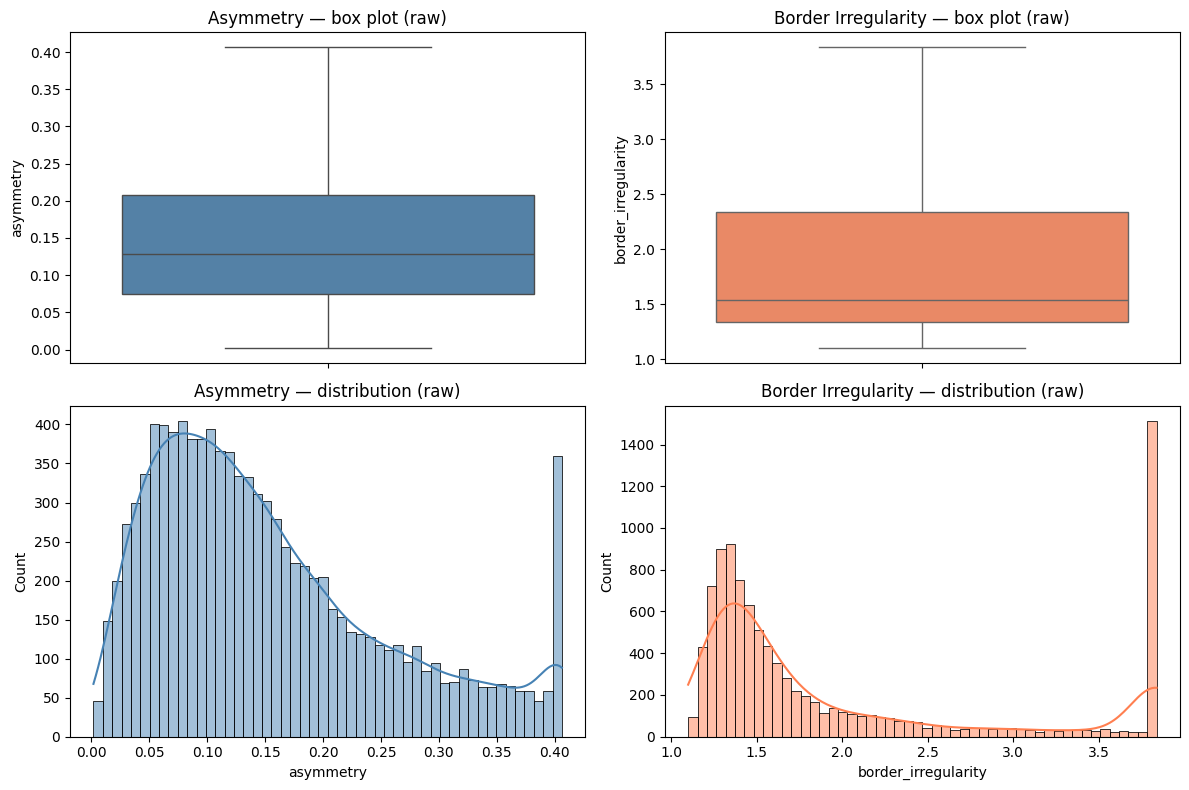

=== Asymmetry (raw) ===
count    10015.000000
mean         0.153422
std          0.102163
min          0.001709
25%          0.074829
50%          0.128418
75%          0.207397
max          0.406250
Name: asymmetry, dtype: float64
Values > 0.5 : 0
Values > 0.8 : 0

=== Border Irregularity (raw) ===
count    10015.000000
mean         1.996744
std          0.925773
min          1.098576
25%          1.338623
50%          1.542302
75%          2.338125
max          3.837380
Name: border_irregularity, dtype: float64
Values > 5   : 0
Values > 15  : 0
Values > 50  : 0

=== IQR upper fences ===
  asymmetry             : upper fence = 0.4062, outliers above = 0
  border_irregularity   : upper fence = 3.8374, outliers above = 0

✅ Outliers capped at IQR upper fence. New stats:
          asymmetry  border_irregularity
count  10015.000000         10015.000000
mean       0.153422             1.996744
std        0.102163             0.925773
min        0.001709             1.098576
25%        0.07

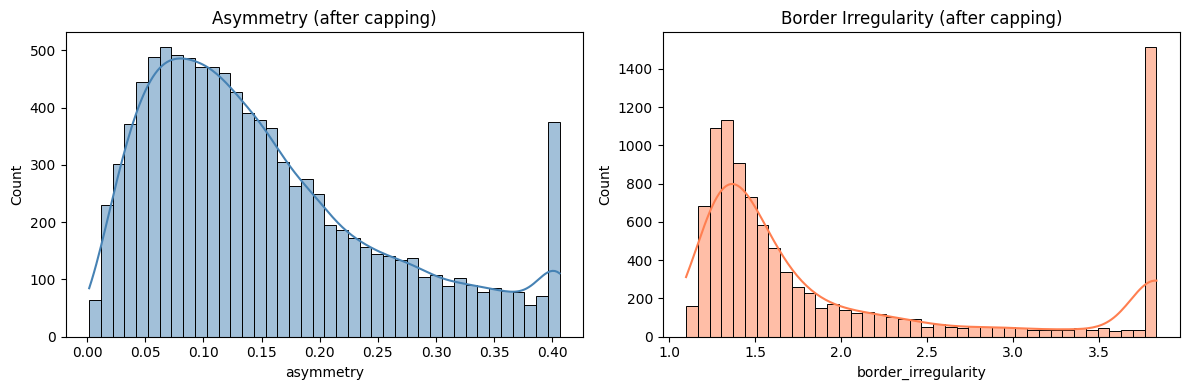

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Visual inspection ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(y=abcd_df["asymmetry"],           ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Asymmetry — box plot (raw)")

sns.boxplot(y=abcd_df["border_irregularity"], ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Border Irregularity — box plot (raw)")

sns.histplot(abcd_df["asymmetry"],           bins=50, kde=True, ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Asymmetry — distribution (raw)")

sns.histplot(abcd_df["border_irregularity"], bins=50, kde=True, ax=axes[1, 1], color="coral")
axes[1, 1].set_title("Border Irregularity — distribution (raw)")

plt.tight_layout()
plt.show()

# ── 2. Stats ──────────────────────────────────────────────────────────
print("=== Asymmetry (raw) ===")
print(abcd_df["asymmetry"].describe())
print(f"Values > 0.5 : {(abcd_df["asymmetry"] > 0.5).sum()}")
print(f"Values > 0.8 : {(abcd_df["asymmetry"] > 0.8).sum()}")

print("\n=== Border Irregularity (raw) ===")
print(abcd_df["border_irregularity"].describe())
print(f"Values > 5   : {(abcd_df["border_irregularity"] > 5).sum()}")
print(f"Values > 15  : {(abcd_df["border_irregularity"] > 15).sum()}")
print(f"Values > 50  : {(abcd_df["border_irregularity"] > 50).sum()}")

# ── 3. IQR fences ────────────────────────────────────────────────────
print("\n=== IQR upper fences ===")
for col in ["asymmetry", "border_irregularity"]:
    Q1    = abcd_df[col].quantile(0.25)
    Q3    = abcd_df[col].quantile(0.75)
    IQR   = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    n_out = (abcd_df[col] > upper).sum()
    print(f"  {col:22s}: upper fence = {upper:.4f}, outliers above = {n_out}")

# ── 4. Cap outliers (Winsorization at IQR upper fence) ───────────────
for col in ["asymmetry", "border_irregularity"]:
    Q1    = abcd_df[col].quantile(0.25)
    Q3    = abcd_df[col].quantile(0.75)
    IQR   = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    abcd_df[col] = abcd_df[col].clip(upper=upper)

print("\n✅ Outliers capped at IQR upper fence. New stats:")
print(abcd_df[["asymmetry", "border_irregularity"]].describe())

# ── 5. After-capping plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(abcd_df["asymmetry"],           bins=40, kde=True, ax=axes[0], color="steelblue")
sns.histplot(abcd_df["border_irregularity"], bins=40, kde=True, ax=axes[1], color="coral")
axes[0].set_title("Asymmetry (after capping)")
axes[1].set_title("Border Irregularity (after capping)")
plt.tight_layout()
plt.show()


In [42]:
import pandas as pd

glcm_df = df.copy()

print(f"GLCM rows : {len(glcm_df)}")
print(f"HSV  rows : {len(hsv_df)}")
print(f"ABCD rows : {len(abcd_df)}")

# ── All three were built by the same folder loop, same order ──────────
# GLCM has no image_id, so we align by position (reset index first)
glcm_reset  = glcm_df.reset_index(drop=True)
hsv_reset   = hsv_df.drop(columns=["image_id", "label"], errors="ignore").reset_index(drop=True)
abcd_reset  = abcd_df.drop(columns=["image_id", "label"], errors="ignore").reset_index(drop=True)

# Sanity check — row counts must match
assert len(glcm_reset) == len(hsv_reset) == len(abcd_reset), \
    f"Row mismatch! GLCM={len(glcm_reset)}, HSV={len(hsv_reset)}, ABCD={len(abcd_reset)}"

# ── Concatenate side by side ──────────────────────────────────────────
merged = pd.concat([glcm_reset, hsv_reset, abcd_reset], axis=1)

print("\nMerged shape:", merged.shape)

# ── X / y split ───────────────────────────────────────────────────────
y    = merged["label"]
X_df = merged.drop(columns=["label"])

print("Final X shape:", X_df.shape)
print("Target shape :", y.shape)

# ── Column group summary ──────────────────────────────────────────────
glcm_cols  = [c for c in X_df.columns if any(c.startswith(p)
              for p in ["contrast","dissimilarity","homogeneity","energy","correlation"])]
hsv_cols_f = [c for c in X_df.columns if c.startswith(("H_","S_","V_"))]
abcd_cols_f = [c for c in X_df.columns if c in ["asymmetry","border_irregularity"]]
print(f"\nFeature groups:")
print(f"  GLCM : {len(glcm_cols)} cols")
print(f"  HSV  : {len(hsv_cols_f)} cols")
print(f"  ABCD : {len(abcd_cols_f)} cols")
print(f"  TOTAL: {X_df.shape[1]} cols")

# ── NaN check ────────────────────────────────────────────────────────
nan_total = X_df.isnull().sum().sum()
print(f"\nNaN values in X: {nan_total}")
if nan_total > 0:
    from sklearn.impute import SimpleImputer
    imp  = SimpleImputer(strategy="median")
    X_df = pd.DataFrame(imp.fit_transform(X_df), columns=X_df.columns)
    print("Imputed with column median")
else:
    print("Clean — no NaNs")

print("\nClass distribution:")
print(y.value_counts())

GLCM rows : 10015
HSV  rows : 10015
ABCD rows : 10015

Merged shape: (10015, 71)
Final X shape: (10015, 70)
Target shape : (10015,)

Feature groups:
  GLCM : 20 cols
  HSV  : 48 cols
  ABCD : 2 cols
  TOTAL: 70 cols

NaN values in X: 0
Clean — no NaNs

Class distribution:
label
HAM10000_images_part_2    5015
HAM10000_images_part_1    5000
Name: count, dtype: int64


In [43]:
# Check what the original metadata looks like
print(df.head())
print()
# Also check if there's a metadata CSV loaded earlier in the notebook
# Look for the actual class column (usually 'dx' in HAM10000)

   contrast_0  contrast_45  contrast_90  contrast_135  dissimilarity_0  \
0   41.972256    57.618637    29.921567     39.119164         4.020731   
1   34.233391    36.703019    20.997047     41.314527         3.727854   
2   70.184916    77.891686    81.910556    117.511625         5.437746   
3   21.315330    23.431769    18.451280     31.397731         3.355438   
4  116.412771   139.067580    94.028851    160.321161         7.842028   

   dissimilarity_45  dissimilarity_90  dissimilarity_135  homogeneity_0  \
0          4.596379          3.389456           4.299895       0.257174   
1          3.962490          3.273622           4.288425       0.263879   
2          5.691549          5.762672           7.079484       0.232783   
3          3.557877          3.107160           4.053568       0.266915   
4          8.470767          7.013472           9.224750       0.134927   

   homogeneity_45  ...  homogeneity_135  energy_0  energy_45  energy_90  \
0        0.232724  ...       

In [44]:
# Check what metadata files are available
import os
for f in os.listdir("."):
    if f.endswith(".csv"):
        print(f)

HAM10000_metadata.csv


In [45]:
import pandas as pd

# ── Load metadata and map real labels ────────────────────────────────
meta = pd.read_csv("HAM10000_metadata.csv")
print("Metadata columns:", list(meta.columns))
print("\nClass distribution:")
print(meta["dx"].value_counts())

# ── Use image_id from abcd_df to map real labels ──────────────────────
image_ids = abcd_df["image_id"].reset_index(drop=True)
id_to_label = dict(zip(meta["image_id"], meta["dx"]))
y = image_ids.map(id_to_label)

print("\nMapped label distribution:")
print(y.value_counts())
print(f"Unmapped (NaN): {y.isnull().sum()}")

Metadata columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Mapped label distribution:
image_id
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
Unmapped (NaN): 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

os.makedirs("models", exist_ok=True)

# ── Label encode ──────────────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", list(le.classes_))

# ── Train/Test split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# ── SMOTE on train only ───────────────────────────────────────────────
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"After SMOTE: {X_train_sm.shape}")
print("SMOTE class counts:", pd.Series(y_train_sm).value_counts().to_dict())

# ── Scale ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

pickle.dump(scaler, open("models/scaler.pkl", "wb"))
pickle.dump(le,     open("models/label_encoder.pkl", "wb"))

# ── Helpers ───────────────────────────────────────────────────────────
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(9,7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()
    return model

# ── SVM ───────────────────────────────────────────────────────────────
svm = evaluate("SVM (RBF)", SVC(C=10, kernel="rbf", probability=True, random_state=42),
               X_train_sc, y_train_sm, X_test_sc, y_test)
pickle.dump(svm, open("models/svm.pkl", "wb"))

# ── Random Forest ─────────────────────────────────────────────────────
rf = evaluate("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
              X_train_sc, y_train_sm, X_test_sc, y_test)
pickle.dump(rf, open("models/random_forest.pkl", "wb"))

# ── XGBoost ───────────────────────────────────────────────────────────
xgb = evaluate("XGBoost", XGBClassifier(n_estimators=300, learning_rate=0.05,
               max_depth=6, use_label_encoder=False,
               eval_metric="mlogloss", random_state=42, n_jobs=-1),
               X_train_sc, y_train_sm, X_test_sc, y_test)
pickle.dump(xgb, open("models/xgboost.pkl", "wb"))

print("\nAll models saved to models/")

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train: (8012, 70), Test: (2003, 70)
After SMOTE: (37548, 70)

Training SVM...
Done.
Training Random Forest...
Done.
Training XGBoost...
Done.


In [47]:
# ── Stage 8: Model Evaluation ────────────────────────────────────────────
# Computes for each model and each class:
#   Accuracy    = correct predictions / total predictions
#   Sensitivity = TP / (TP + FN)  → how well it catches true positives
#   Specificity = TN / (TN + FP)  → how well it avoids false alarms

import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = list(le.classes_)

def compute_metrics(y_true, y_pred, class_names):
    """
    For each class compute Sensitivity and Specificity
    using one-vs-rest confusion matrix breakdown.

    Returns a DataFrame with columns:
        Class | Sensitivity | Specificity | TP | FP | TN | FN
    """
    cm = confusion_matrix(y_true, y_pred)
    rows = []
    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP          # missed positives
        FP = cm[:, i].sum() - TP          # false alarms
        TN = cm.sum() - TP - FN - FP      # correct negatives

        sensitivity = TP / (TP + FN + 1e-9)
        specificity = TN / (TN + FP + 1e-9)

        rows.append({
            "Class":       cls,
            "TP":          int(TP),
            "FP":          int(FP),
            "TN":          int(TN),
            "FN":          int(FN),
            "Sensitivity": round(sensitivity, 3),
            "Specificity": round(specificity, 3),
        })
    return pd.DataFrame(rows)

# ── Run evaluation for all 3 models ──────────────────────────────────────
models = {
    "SVM":           svm_model,
    "Random Forest": rf_model,
    "XGBoost":       xgb_model,
}

results = {}
print("=" * 65)
for name, model in models.items():
    y_pred = model.predict(X_test_sc)
    acc    = accuracy_score(y_test, y_pred)
    df_ss  = compute_metrics(y_test, y_pred, CLASS_NAMES)
    results[name] = {"y_pred": y_pred, "accuracy": acc, "metrics": df_ss}

    print(f"\n{'─'*65}")
    print(f"  {name}   —   Overall Accuracy: {acc*100:.2f}%")
    print(f"{'─'*65}")
    print(df_ss[["Class","Sensitivity","Specificity","TP","FP","TN","FN"]].to_string(index=False))

print("\n" + "=" * 65)


─────────────────────────────────────────────────────────────────
  SVM   —   Overall Accuracy: 71.94%
─────────────────────────────────────────────────────────────────
Class  Sensitivity  Specificity   TP  FP   TN  FN
akiec        0.446        0.979   29  41 1897  36
  bcc        0.437        0.960   45  76 1824  58
  bkl        0.459        0.940  101 107 1676 119
   df        0.217        0.994    5  11 1969  18
  mel        0.430        0.928   96 128 1652 127
   nv        0.863        0.715 1157 189  473 184
 vasc        0.286        0.995    8  10 1965  20

─────────────────────────────────────────────────────────────────
  Random Forest   —   Overall Accuracy: 71.89%
─────────────────────────────────────────────────────────────────
Class  Sensitivity  Specificity   TP  FP   TN  FN
akiec        0.369        0.984   24  31 1907  41
  bcc        0.524        0.956   54  84 1816  49
  bkl        0.464        0.933  102 119 1664 118
   df        0.174        0.994    4  11 1969  19


In [48]:
# ── Summary Table: Accuracy + Macro Sensitivity + Specificity ───────────
from sklearn.metrics import classification_report

summary_rows = []
for name, res in results.items():
    rep    = classification_report(y_test, res["y_pred"],
                                   target_names=CLASS_NAMES, output_dict=True)
    avg_ss = res["metrics"][["Sensitivity","Specificity"]].mean()
    summary_rows.append({
        "Model":               name,
        "Accuracy (%)":        round(res["accuracy"] * 100, 2),
        "Macro Precision":     round(rep["macro avg"]["precision"], 3),
        "Macro Recall":        round(rep["macro avg"]["recall"],    3),
        "Macro F1":            round(rep["macro avg"]["f1-score"],  3),
        "Avg Sensitivity":     round(avg_ss["Sensitivity"],         3),
        "Avg Specificity":     round(avg_ss["Specificity"],         3),
    })

summary_df = pd.DataFrame(summary_rows)
print("\nMODEL COMPARISON SUMMARY")
print("=" * 75)
print(summary_df.to_string(index=False))
summary_df.to_csv("model_comparison.csv", index=False)
print("\nSaved → model_comparison.csv")

# Highlight best model
best = summary_df.loc[summary_df["Macro F1"].idxmax(), "Model"]
print(f"\nBest model by Macro F1: {best}")


MODEL COMPARISON SUMMARY
        Model  Accuracy (%)  Macro Precision  Macro Recall  Macro F1  Avg Sensitivity  Avg Specificity
          SVM         71.94            0.474         0.448     0.457            0.448            0.930
Random Forest         71.89            0.470         0.451     0.455            0.451            0.933
      XGBoost         72.84            0.487         0.475     0.480            0.475            0.930

Saved → model_comparison.csv

Best model by Macro F1: XGBoost


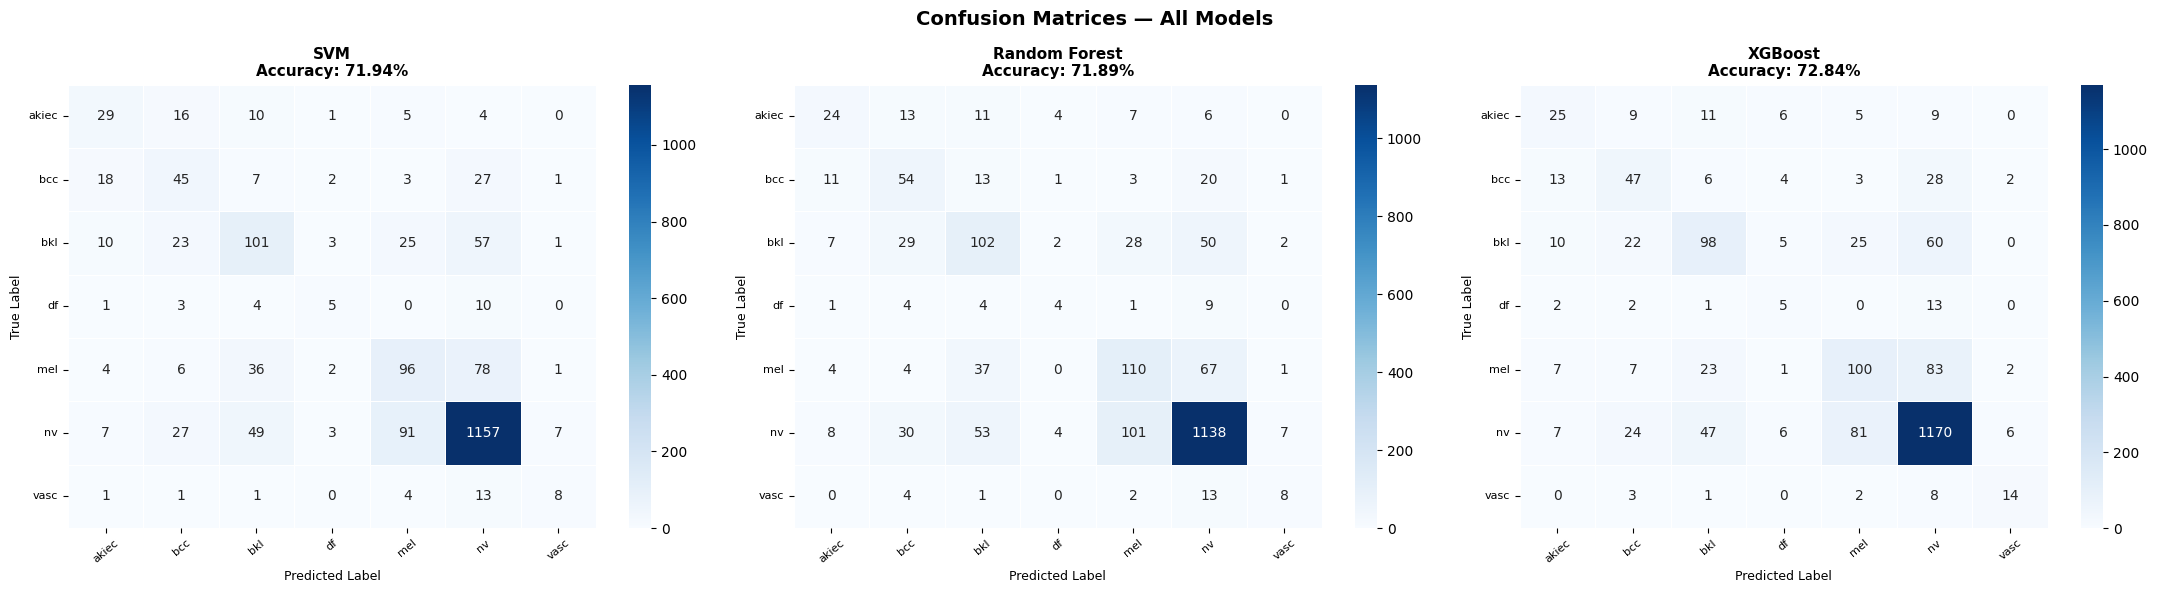

In [49]:
# ── Plot 1: Confusion Matrices for all 3 models ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5
    )
    acc = res["accuracy"] * 100
    ax.set_title(f"{name}\nAccuracy: {acc:.2f}%", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontsize=9)
    ax.set_ylabel("True Label", fontsize=9)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()

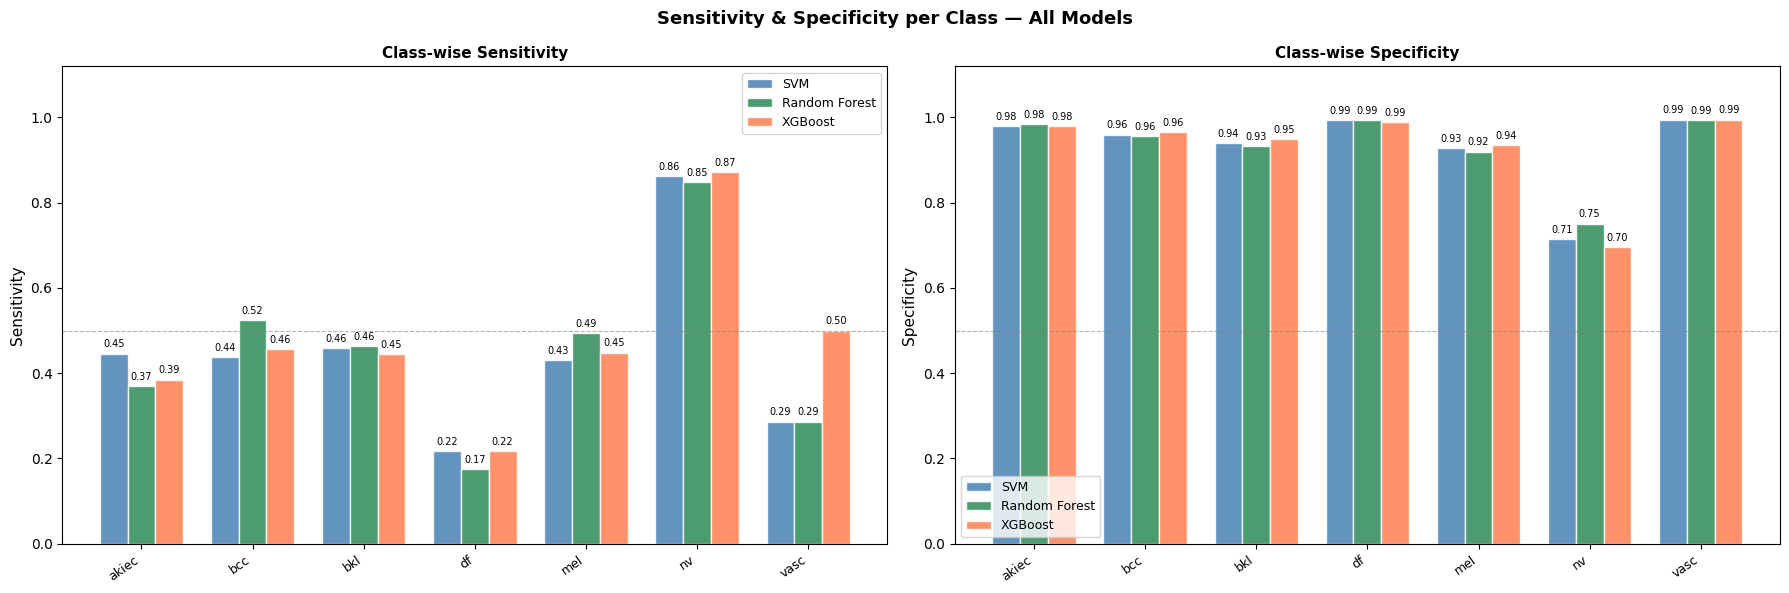

In [50]:
# ── Plot 2: Class-wise Sensitivity & Specificity — All Models ────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Sensitivity & Specificity per Class — All Models",
             fontsize=13, fontweight='bold')

x      = np.arange(len(CLASS_NAMES))
width  = 0.25
colors = ["steelblue", "seagreen", "coral"]

for ax, metric in zip(axes, ["Sensitivity", "Specificity"]):
    for i, (name, res) in enumerate(results.items()):
        vals = res["metrics"][metric].values
        bars = ax.bar(x + i * width, vals, width,
                      label=name, color=colors[i], alpha=0.85, edgecolor='white')
        # Value labels on bars
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"{v:.2f}", ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"Class-wise {metric}", fontsize=11, fontweight='bold')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=9)

plt.tight_layout()

plt.show()

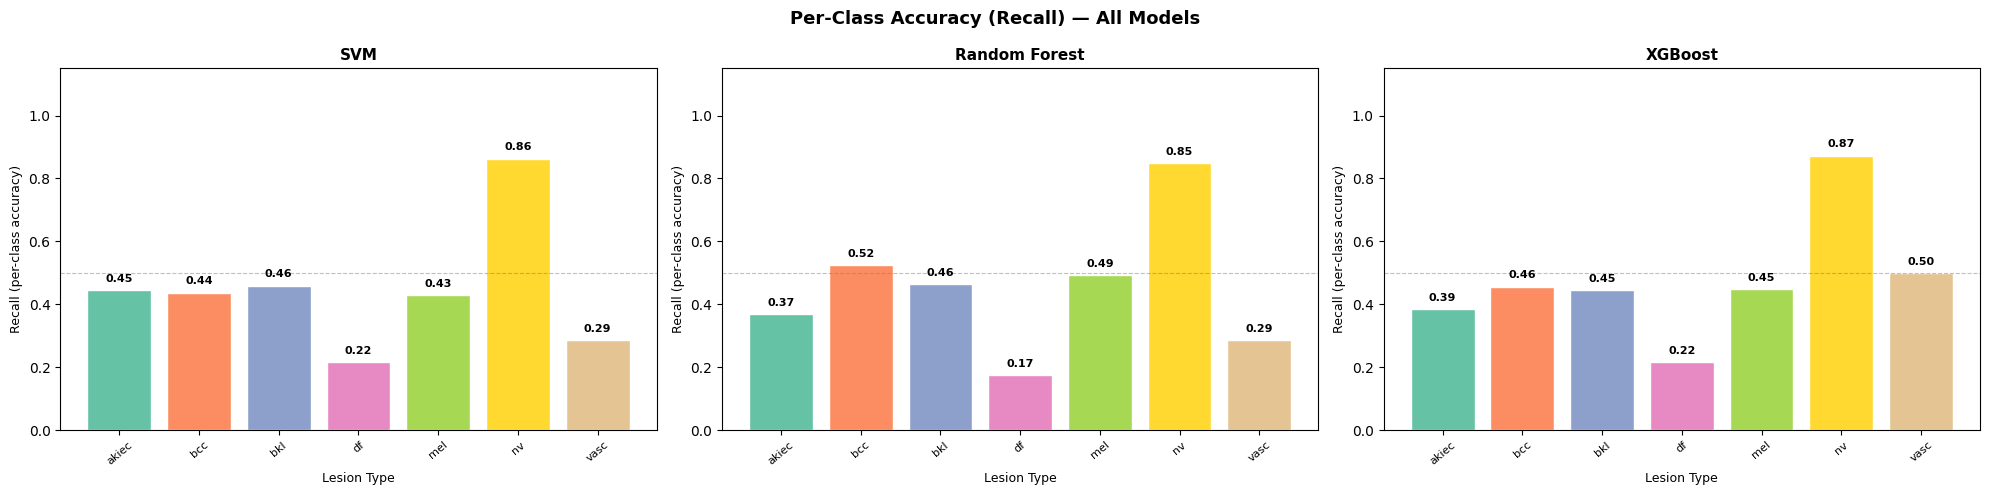

In [51]:
# ── Plot 3: Per-Class Accuracy (Recall) for each model ───────────────────
from sklearn.metrics import classification_report

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Per-Class Accuracy (Recall) — All Models",
             fontsize=13, fontweight='bold')

palette = sns.color_palette("Set2", len(CLASS_NAMES))

for ax, (name, res) in zip(axes, results.items()):
    rep  = classification_report(y_test, res["y_pred"],
                                 target_names=CLASS_NAMES, output_dict=True)
    recalls = [round(rep[c]["recall"], 3) for c in CLASS_NAMES]

    bars = ax.bar(CLASS_NAMES, recalls, color=palette, edgecolor='white')
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Lesion Type", fontsize=9)
    ax.set_ylabel("Recall (per-class accuracy)", fontsize=9)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    for bar, v in zip(bars, recalls):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f"{v:.2f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()

plt.show()

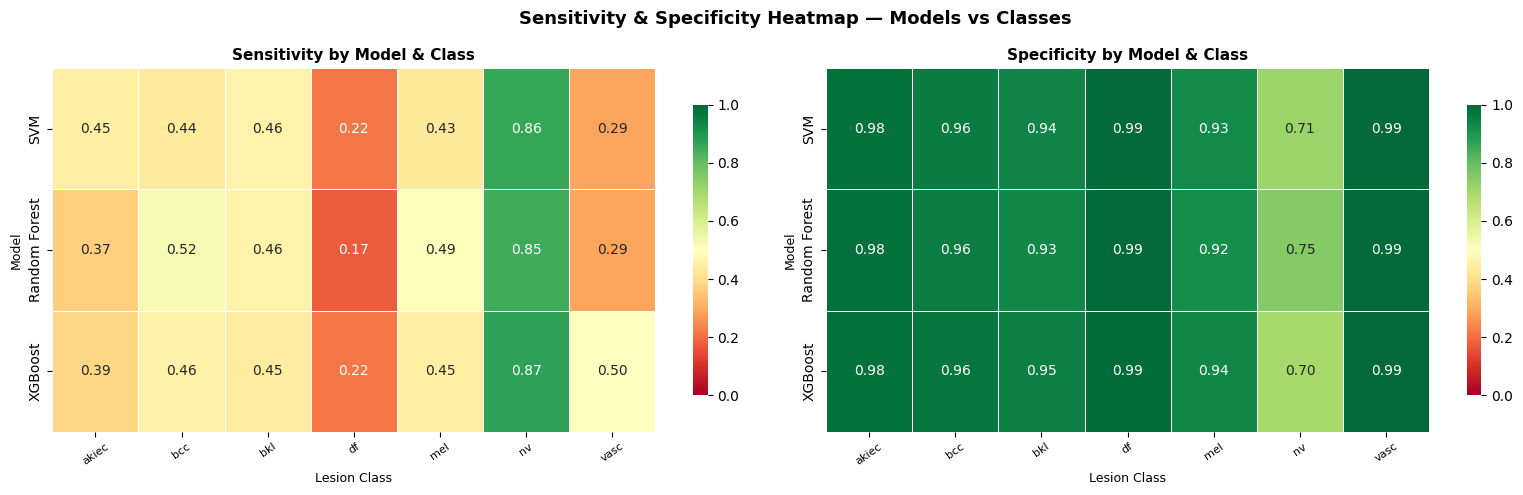

In [52]:
# ── Plot 4: Sensitivity Heatmap — Models × Classes ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Sensitivity & Specificity Heatmap — Models vs Classes",
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ["Sensitivity", "Specificity"]):
    heat_data = pd.DataFrame(
        {name: res["metrics"].set_index("Class")[metric]
         for name, res in results.items()}
    ).T   # rows = models, cols = classes

    sns.heatmap(
        heat_data, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=0, vmax=1, linewidths=0.5,
        ax=ax, cbar_kws={"shrink": 0.8}
    )
    ax.set_title(f"{metric} by Model & Class", fontsize=11, fontweight='bold')
    ax.set_xlabel("Lesion Class", fontsize=9)
    ax.set_ylabel("Model", fontsize=9)
    ax.tick_params(axis='x', rotation=35, labelsize=8)

plt.tight_layout()

plt.show()

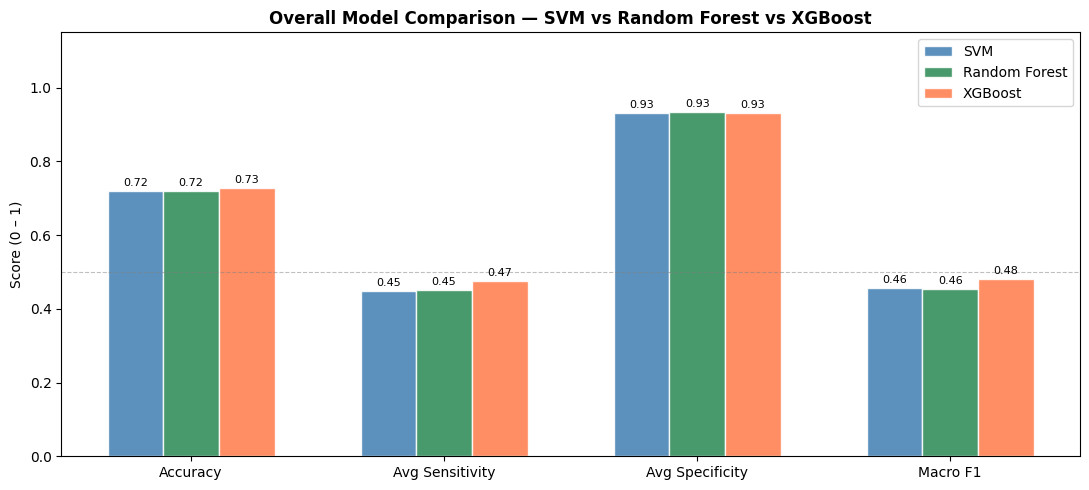


EVALUATION COMPLETE — FILES SAVED
  confusion_matrices.png               Confusion matrix for all 3 models
  sensitivity_specificity.png          Class-wise sensitivity & specificity
  per_class_accuracy.png               Per-class recall for all models
  metrics_heatmap.png                  Sensitivity/specificity heatmap
  model_comparison_chart.png           Overall model comparison bar chart
  model_comparison.csv                 Numeric summary table

Best model: XGBoost  (highest Macro F1)


In [53]:
# ── Plot 5: Overall Model Comparison Bar Chart ───────────────────────────
metrics_to_plot = ["Accuracy (%)", "Avg Sensitivity", "Avg Specificity", "Macro F1"]

# Normalize accuracy to 0-1 for same scale
plot_df = summary_df.copy()
plot_df["Accuracy (%)"] = plot_df["Accuracy (%)"] / 100

fig, ax = plt.subplots(figsize=(11, 5))

x     = np.arange(len(metrics_to_plot))
width = 0.22
colors = ["steelblue", "seagreen", "coral"]

for i, (_, row) in enumerate(plot_df.iterrows()):
    vals = [row["Accuracy (%)"], row["Avg Sensitivity"],
            row["Avg Specificity"], row["Macro F1"]]
    bars = ax.bar(x + i * width, vals, width,
                  label=row["Model"], color=colors[i],
                  alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{v:.2f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(["Accuracy", "Avg Sensitivity", "Avg Specificity", "Macro F1"],
                   fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score (0 – 1)", fontsize=10)
ax.set_title("Overall Model Comparison — SVM vs Random Forest vs XGBoost",
             fontsize=12, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=10)

plt.tight_layout()

plt.show()


# ── Final printed summary ─────────────────────────────────────────────────
print("\n" + "=" * 65)
print("EVALUATION COMPLETE — FILES SAVED")
print("=" * 65)
outputs = [
    ("confusion_matrices.png",     "Confusion matrix for all 3 models"),
    ("sensitivity_specificity.png","Class-wise sensitivity & specificity"),
    ("per_class_accuracy.png",     "Per-class recall for all models"),
    ("metrics_heatmap.png",        "Sensitivity/specificity heatmap"),
    ("model_comparison_chart.png", "Overall model comparison bar chart"),
    ("model_comparison.csv",       "Numeric summary table"),
]
for fname, desc in outputs:
    print(f"  {fname:<35}  {desc}")

print(f"\nBest model: {best}  (highest Macro F1)")